In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import scipy
from datetime import datetime
import statsmodels.formula.api as smf

from matplotlib import style
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.font_manager import FontProperties
from pylab import mpl
import platform

# 根据操作系统设置中文字体
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.sans-serif'] = ['SimHei']  # Windows使用黑体
    plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题
elif system == 'Darwin':  # macOS
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macOS使用Arial Unicode MS
    plt.rcParams['axes.unicode_minus'] = False
else:  # Linux
    plt.rcParams['font.sans-serif'] = ['WenQuanYi Micro Hei']  # Linux使用文泉驿微米黑
    plt.rcParams['axes.unicode_minus'] = False

# 输出矢量图
%matplotlib inline
%config InlineBackend.figure_format = 'svg'

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = 'all'

# 设置pandas显示选项
pd.set_option('display.max_columns', None)

print(f"当前操作系统: {system}")
print(f"字体设置: {plt.rcParams['font.sans-serif']}")

当前操作系统: Windows
字体设置: ['SimHei']


In [2]:
cross = pd.read_csv(r"D:\class1\TRD_Mnth202509.csv")
from pandas.tseries.offsets import MonthEnd
# 处理月份格式
cross['month'] = pd.to_datetime(cross['Trdmnt'], format='%Y-%m') + MonthEnd(1)
# 补齐股票代码 如果不满6位 在前面补上0
cross['Stkcd'] = cross['Stkcd'].apply(lambda x: '{:0>6}'.format(x)) # 6位股票代码
# 重命名列以匹配后续代码
cross.rename(columns={'Mretwd': 'Return', 'Msmvosd': 'floatingvalue', 'Msmvttl': 'totalvalue'}, inplace=True)

# 导入无风险利率数据
rf_data = pd.read_csv(r"D:\class1\Marketret_mon_stock2024.csv")
# 处理月份格式
rf_data['month'] = pd.to_datetime(rf_data['month'], format='%b %Y') + MonthEnd(1)
# 只保留需要的列
rf_data = rf_data[['month', 'rfmonth']]

# 合并无风险利率到cross
cross = pd.merge(cross, rf_data, on='month', how='left')

# 添加一个序列 用来统计公司上市的第几个月
cross = cross.sort_values(by=['Stkcd', 'month'])
cross['list_month'] = cross.groupby('Stkcd').cumcount() + 1

# 计算超额收益率
cross['ret'] = cross['Return'] - cross['rfmonth']
cross['floatingvalue'] = cross['floatingvalue'] * 1000
cross['totalvalue'] = cross['totalvalue'] * 1000

cross

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret
0,000001,1991-04,3,49.00,30,43.68,13400,6.150000e+05,1.157520e+09,2.118487e+09,20,NaN,NaN,4,1991-04-03,NaN,NaN,1991-04-30,0.006651,1,NaN
1,000001,1991-05,2,43.46,31,38.34,187800,7.675000e+06,1.016010e+09,1.859497e+09,24,-0.122253,0.235714,4,1991-04-03,NaN,NaN,1991-05-31,0.006092,2,-0.128345
2,000001,1991-06,1,38.53,28,33.99,30600,1.094000e+06,9.007350e+08,1.648521e+09,23,-0.113459,-0.113459,4,1991-04-03,NaN,NaN,1991-06-30,0.006092,3,-0.119551
3,000001,1991-07,1,33.65,31,29.54,6100,1.940430e+05,7.828100e+08,1.432695e+09,16,-0.130921,-0.130921,4,1991-04-03,NaN,NaN,1991-07-31,0.006092,4,-0.137013
4,000001,1991-08,1,29.39,31,15.00,3243100,4.957624e+07,6.748338e+08,1.346275e+09,15,-0.411588,-0.411587,4,1991-08-01,NaN,NaN,1991-08-31,0.006092,5,-0.417680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886908,920992,2025-05,6,20.00,30,20.46,92609592,1.922463e+09,5.707967e+08,1.979115e+09,19,0.051312,0.051715,64,2023-04-25,0.0,0.0,2025-05-31,NaN,32,NaN
886909,920992,2025-06,3,20.40,30,21.26,73152031,1.580767e+09,5.931152e+08,2.056500e+09,20,0.039101,0.039101,64,2023-04-25,0.0,0.0,2025-06-30,NaN,33,NaN
886910,920992,2025-07,1,21.13,31,22.44,96064221,2.126994e+09,6.260351e+08,2.170642e+09,23,0.055503,0.055503,64,2023-04-25,0.0,0.0,2025-07-31,NaN,34,NaN
886911,920992,2025-08,1,22.12,29,21.65,63953451,1.432608e+09,6.039955e+08,2.094225e+09,21,-0.035205,-0.035205,64,2023-04-25,0.0,0.0,2025-08-31,NaN,35,NaN


In [3]:
# 生成下一个月的收益率

# 方法1：补全所有个股的日期序列，再使用shift
# 创建所有日期和股票代码的完整组合
all_months = pd.DataFrame(cross['month'].unique(), columns=['month'])
all_stocks = pd.DataFrame(cross['Stkcd'].unique(), columns=['Stkcd'])
# 创建笛卡尔积 - 所有股票和所有月份的组合
full_index = all_stocks.merge(all_months, how='cross')

# 将原始数据合并到完整索引中
cross_full = full_index.merge(cross, on=['Stkcd', 'month'], how='left')
# 按股票代码和月份排序
cross_full = cross_full.sort_values(['Stkcd', 'month'])
# 使用shift生成下月收益率
cross_full['next_ret'] = cross_full.groupby('Stkcd')['ret'].shift(-1)

# 只保留原始数据存在的行
cross = cross.merge(cross_full[['Stkcd', 'month', 'next_ret']], 
                    on=['Stkcd', 'month'], how='right')

# 添加一个变量 用来统计过去一年的交易日数量之和
cross['Cumsum_tradingday'] = cross.groupby('Stkcd')['Ndaytrd'].transform(lambda x: x.rolling(window=12, min_periods=1).sum())
print("方法1完成：补全日期序列后使用shift")

cross = cross[(cross['month'] >= '1995-01-31') & (cross['month'] <= '2024-12-31')]
cross

方法1完成：补全日期序列后使用shift


,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday
49,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0
50,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0
51,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0
52,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0
53,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2453228,920992,2024-08,1.0,8.50,30.0,8.19,14436632.0,1.185912e+08,2.284861e+08,7.922264e+08,22.0,-0.037603,-0.037603,64.0,2023-04-25,0.0,0.0,2024-08-31,0.001118,23.0,-0.038721,0.276049,242.0
2453229,920992,2024-09,2.0,8.15,30.0,10.46,18109819.0,1.566140e+08,2.918149e+08,1.011806e+09,19.0,0.277167,0.277167,64.0,2023-04-25,0.0,0.0,2024-09-30,0.001118,24.0,0.276049,0.389895,241.0
2453230,920992,2024-10,8.0,13.02,31.0,14.55,86774237.0,1.145494e+09,4.059185e+08,1.407435e+09,18.0,0.391013,0.391013,64.0,2023-04-25,0.0,0.0,2024-10-31,0.001118,25.0,0.389895,0.241494,242.0
2453231,920992,2024-11,1.0,14.69,29.0,18.08,130783392.0,2.346534e+09,5.043990e+08,1.748895e+09,21.0,0.242612,0.242612,64.0,2023-04-25,0.0,0.0,2024-11-30,0.001118,26.0,0.241494,-0.243928,241.0


In [8]:
from pandas.tseries.offsets import MonthEnd # 月末
Market_ret = pd.read_csv(r"D:\class1\Marketret_mon_stock2024.csv")
Market_ret['month'] = pd.to_datetime(Market_ret['month'])+ MonthEnd(0)
Market_ret.set_index('month', inplace=True)
Market_ret.sort_index(inplace=True)
Market_ret = Market_ret.drop(columns=['Unnamed: 0'])
Market_ret.rename(columns={'ret': 'MKT'}, inplace=True)
Market_ret

C:\Users\sa'si'gei\AppData\Local\Temp\ipykernel_15924\1461743994.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  Market_ret['month'] = pd.to_datetime(Market_ret['month'])+ MonthEnd(0)


,MarketR,MarketR_e,rfmonth,MKT,ret_e,marketret3,marketret6,marketret12,Q
month,,,,,,,,,
1991-01-31,0.029998,0.036554,0.006930,0.023068,0.029624,-0.084127,-0.305662,0.254049,1991 Q1
1991-02-28,0.010203,0.021860,0.006930,0.003273,0.014930,-0.183573,-0.384745,0.241492,1991 Q1
1991-03-31,-0.099663,-0.060425,0.006930,-0.106593,-0.067355,-0.252928,-0.445049,0.288857,1991 Q1
1991-04-30,-0.079652,-0.031449,0.006651,-0.086303,-0.038100,-0.234776,-0.394937,0.691749,1991 Q2
1991-05-31,-0.074521,0.005375,0.006092,-0.080613,-0.000717,-0.236294,0.181673,1.542701,1991 Q2
...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.031468,-0.033685,0.001118,-0.032586,-0.034803,0.151050,NaN,NaN,2024 Q3
2024-09-30,0.195992,0.227078,0.001118,0.194874,0.225960,0.200147,NaN,NaN,2024 Q3
2024-10-31,-0.003409,0.070220,0.001118,-0.004527,0.069102,0.000228,NaN,NaN,2024 Q4


In [9]:
cross = pd.merge(cross,Market_ret[['MKT']],left_on='month',right_on='month',how='left')
cross

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2112835,920992,2024-08,1.0,8.50,30.0,8.19,14436632.0,1.185912e+08,2.284861e+08,7.922264e+08,22.0,-0.037603,-0.037603,64.0,2023-04-25,0.0,0.0,2024-08-31,0.001118,23.0,-0.038721,0.276049,242.0,-0.032586
2112836,920992,2024-09,2.0,8.15,30.0,10.46,18109819.0,1.566140e+08,2.918149e+08,1.011806e+09,19.0,0.277167,0.277167,64.0,2023-04-25,0.0,0.0,2024-09-30,0.001118,24.0,0.276049,0.389895,241.0,0.194874
2112837,920992,2024-10,8.0,13.02,31.0,14.55,86774237.0,1.145494e+09,4.059185e+08,1.407435e+09,18.0,0.391013,0.391013,64.0,2023-04-25,0.0,0.0,2024-10-31,0.001118,25.0,0.389895,0.241494,242.0,-0.004527
2112838,920992,2024-11,1.0,14.69,29.0,18.08,130783392.0,2.346534e+09,5.043990e+08,1.748895e+09,21.0,0.242612,0.242612,64.0,2023-04-25,0.0,0.0,2024-11-30,0.001118,26.0,0.241494,-0.243928,241.0,0.008606


In [10]:
cross = cross[cross['Ndaytrd'] >= 7]
cross = cross[cross['Clsdt'] >= 5]
cross = cross[cross['list_month'] > 6]
cross = cross[cross['Cumsum_tradingday'] >= 100]
cross = cross[(cross['Markettype'] == 1) | (cross['Markettype'] == 4) | (cross['Markettype'] == 16)]
cross

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1779475,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586
1779476,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874
1779477,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527
1779478,605599,2024-11,1.0,10.63,29.0,11.50,108258572.0,1.199394e+09,8.944445e+09,8.944445e+09,21.0,0.079812,0.079812,1.0,2024-09-09,0.0,0.0,2024-11-30,0.001118,39.0,0.078694,-0.014161,241.0,0.008606


In [11]:
EP = pd.read_csv(r"D:\class1\EP_individual_mon2024.csv")
EP['Stkcd'] = EP['Stkcd'].apply(lambda x: '{:0>6}'.format(x))
# EP['month'] = pd.to_datetime(EP['month'], format='%Y-%m') + MonthEnd(1)
# EP = EP[['Stkcd', 'month', 'EP_individual']]
EP

,Stkcd,month,matchearnings,recent_earnings,floatingvalue,totalvalue,ratio,Clsprc,ep,ep_recent
0,000001,1991.250000,NaN,NaN,1.157520e+09,2.118487e+09,0.54639,43.68,NaN,NaN
1,000001,1991.333333,NaN,NaN,1.016010e+09,1.859497e+09,0.54639,38.34,NaN,NaN
2,000001,1991.416667,NaN,NaN,9.007350e+08,1.648521e+09,0.54639,33.99,NaN,NaN
3,000001,1991.500000,NaN,NaN,7.828100e+08,1.432695e+09,0.54639,29.54,NaN,NaN
4,000001,1991.583333,NaN,NaN,6.748338e+08,1.346275e+09,0.50126,15.00,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
809599,605599,2024.583333,6.614476e+08,3.884148e+08,6.300920e+09,8.353334e+09,0.75430,10.74,0.079184,0.046498
809600,605599,2024.666667,6.614476e+08,3.884148e+08,9.247778e+09,9.247778e+09,1.00000,11.89,0.071525,0.042001
809601,605599,2024.750000,6.455339e+08,5.286127e+08,8.283334e+09,8.283334e+09,1.00000,10.65,0.077932,0.063816
809602,605599,2024.833333,6.455339e+08,5.286127e+08,8.944445e+09,8.944445e+09,1.00000,11.50,0.072171,0.059100


In [13]:
# 重新读取EP数据并转换month列
EP = pd.read_csv(r"D:\class1\EP_individual_mon2024.csv")
EP['Stkcd'] = EP['Stkcd'].apply(lambda x: '{:0>6}'.format(x))

# 转换month列为日期格式
# 根据数据规律: 1991.250000 -> 1991年3月, 1991.333333 -> 1991年4月
# 小数部分 = (month - 1) / 12, 所以 month = round(小数部分 * 12) + 1
EP['year'] = EP['month'].astype(int)
EP['month_decimal'] = EP['month'] - EP['year']
EP['month_num'] = (EP['month_decimal'] * 12).round().astype(int) + 1
# 处理边界情况
EP.loc[EP['month_num'] > 12, 'year'] += 1
EP.loc[EP['month_num'] > 12, 'month_num'] -= 12
EP['month'] = pd.to_datetime(EP['year'].astype(str) + '-' + EP['month_num'].astype(str) + '-01')
EP = EP.drop(['year', 'month_decimal', 'month_num'], axis=1)
EP['month'] = EP['month'] + MonthEnd(1)
EP = EP[['Stkcd', 'month', 'ep', 'ep_recent']]
EP

,Stkcd,month,ep,ep_recent
0,000001,1991-04-30,NaN,NaN
1,000001,1991-05-31,NaN,NaN
2,000001,1991-06-30,NaN,NaN
3,000001,1991-07-31,NaN,NaN
4,000001,1991-08-31,NaN,NaN
...,...,...,...,...
809599,605599,2024-08-31,0.079184,0.046498
809600,605599,2024-09-30,0.071525,0.042001
809601,605599,2024-10-31,0.077932,0.063816
809602,605599,2024-11-30,0.072171,0.059100


In [14]:
cross = pd.merge(cross,EP[['Stkcd','month','ep','ep_recent']],on=['Stkcd','month'],how='left')
cross

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730035,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586,0.079184,0.046498
730036,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874,0.071525,0.042001
730037,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527,0.077932,0.063816
730038,605599,2024-11,1.0,10.63,29.0,11.50,108258572.0,1.199394e+09,8.944445e+09,8.944445e+09,21.0,0.079812,0.079812,1.0,2024-09-09,0.0,0.0,2024-11-30,0.001118,39.0,0.078694,-0.014161,241.0,0.008606,0.072171,0.059100


In [15]:
fenweishu = pd.DataFrame(
    cross.groupby(['month'])['ep'].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]))
fenweishu = fenweishu.reset_index()
fenweishu = fenweishu.pivot_table(index='month',columns='level_1',values='ep')
fenweishu.columns = ['one','two','three','four','five','six','seven','eight','nine']
fenweishu

,one,two,three,four,five,six,seven,eight,nine
month,,,,,,,,,
1995-01-31,0.003740,0.021281,0.033164,0.039819,0.044917,0.052511,0.073509,0.088339,0.108585
1995-02-28,0.017802,0.027244,0.035524,0.039235,0.046534,0.057727,0.068244,0.085852,0.107936
1995-03-31,0.019806,0.025710,0.031130,0.036242,0.039984,0.047927,0.059745,0.079132,0.097067
1995-04-30,0.022996,0.030191,0.037497,0.048093,0.057527,0.068974,0.082006,0.094234,0.118343
1995-05-31,0.019335,0.023981,0.031124,0.039584,0.047728,0.057994,0.069575,0.084349,0.107694
...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.065342,-0.015765,0.001985,0.013019,0.023183,0.033007,0.044546,0.058770,0.081748
2024-09-30,-0.051694,-0.012428,0.001630,0.010812,0.019079,0.027164,0.037395,0.048900,0.068312
2024-10-31,-0.047610,-0.013923,0.000275,0.008623,0.016624,0.025175,0.035106,0.047547,0.067220


In [16]:
portfolio = pd.merge(cross,fenweishu,on='month')
portfolio['sort'] = np.where(
    portfolio['ep'] <= portfolio['one'], 'P1',
    np.where(
        portfolio['ep'] <= portfolio['two'], 'P2',
        np.where(
            portfolio['ep'] <= portfolio['three'], 'P3',
            np.where(
                portfolio['ep'] <= portfolio['four'], 'P4',
                np.where(
                    portfolio['ep'] <= portfolio['five'], 'P5',
                    np.where(
                        portfolio['ep'] <= portfolio['six'], 'P6',
                        np.where(
                            portfolio['ep'] <= portfolio['seven'], 'P7',
                            np.where(
                                portfolio['ep'] <= portfolio['eight'], 'P8',
                                np.where(
                                    portfolio['ep'] <= portfolio['nine'],
                                    'P9', 'Pmax')))))))))
portfolio = portfolio.dropna(subset=['floatingvalue','next_ret','ep'])
portfolio

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent,one,two,three,four,five,six,seven,eight,nine,sort
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427,0.003740,0.021281,0.033164,0.039819,0.044917,0.052511,0.073509,0.088339,0.108585,P8
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763,0.017802,0.027244,0.035524,0.039235,0.046534,0.057727,0.068244,0.085852,0.107936,P8
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823,0.019806,0.025710,0.031130,0.036242,0.039984,0.047927,0.059745,0.079132,0.097067,P8
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306,0.022996,0.030191,0.037497,0.048093,0.057527,0.068974,0.082006,0.094234,0.118343,P8
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349,0.019335,0.023981,0.031124,0.039584,0.047728,0.057994,0.069575,0.084349,0.107694,P8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730034,605599,2024-07,1.0,12.78,31.0,11.49,54949980.0,6.610917e+08,6.740928e+09,8.936667e+09,23.0,-0.097408,-0.097408,1.0,2022-09-09,0.0,0.0,2024-07-31,0.001184,35.0,-0.098592,-0.066392,243.0,-0.000624,0.078272,0.028314,-0.061968,-0.014115,0.003415,0.012878,0.022664,0.032734,0.043958,0.058448,0.081198,P9
730035,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586,0.079184,0.046498,-0.065342,-0.015765,0.001985,0.013019,0.023183,0.033007,0.044546,0.058770,0.081748,P9
730036,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874,0.071525,0.042001,-0.051694,-0.012428,0.001630,0.010812,0.019079,0.027164,0.037395,0.048900,0.068312,Pmax
730037,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527,0.077932,0.063816,-0.047610,-0.013923,0.000275,0.008623,0.016624,0.025175,0.035106,0.047547,0.067220,Pmax


In [17]:
portfolio_value =  pd.DataFrame(
    portfolio.groupby(['month','sort']).apply(lambda x: np.average(x['next_ret'],weights = x['floatingvalue']),include_groups=False))
portfolio_value = portfolio_value.reset_index()
portfolio_value.columns = ['month', 'sort', 'p']
portfolio_value['month'] = portfolio_value['month'] + MonthEnd(1)
portfolio_value

,month,sort,p
0,1995-02-28,P1,-0.046564
1,1995-02-28,P2,-0.039864
2,1995-02-28,P3,0.004335
3,1995-02-28,P4,0.010141
4,1995-02-28,P5,-0.046855
...,...,...,...
3585,2024-12-31,P6,-0.020564
3586,2024-12-31,P7,-0.021901
3587,2024-12-31,P8,-0.000751
3588,2024-12-31,P9,0.001804


In [18]:
portfolio_value = portfolio_value.pivot_table(index='month',
                                                    columns='sort',
                                                    values='p')
portfolio_value['My_portfolio'] = portfolio_value['Pmax'] - portfolio_value['P1']
portfolio_value

sort,P1,P2,P3,P4,P5,P6,P7,P8,P9,Pmax,My_portfolio
month,,,,,,,,,,,
1995-02-28,-0.046564,-0.039864,0.004335,0.010141,-0.046855,-0.014133,0.004822,0.004398,0.005364,-0.004510,0.042054
1995-03-31,0.166651,0.039614,0.186807,0.105647,0.145939,0.211369,0.125131,0.011332,0.115488,0.033143,-0.133508
1995-04-30,-0.120087,-0.098151,-0.098700,-0.116309,-0.102409,-0.120334,-0.137053,-0.103988,-0.097787,-0.116950,0.003137
1995-05-31,0.169245,0.211190,0.224196,0.246332,0.226090,0.166345,0.208711,0.125688,0.106342,0.059119,-0.110126
1995-06-30,-0.101912,-0.111554,-0.118523,-0.122750,-0.120498,-0.086887,-0.073876,-0.080503,-0.079607,-0.063207,0.038705
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.038232,-0.053478,-0.049764,-0.065088,-0.056185,-0.036431,-0.038029,-0.032099,-0.029894,-0.017219,0.021013
2024-09-30,0.291391,0.265119,0.228272,0.232738,0.215657,0.219249,0.195558,0.235590,0.203023,0.137434,-0.153957
2024-10-31,0.136777,0.144915,0.086483,0.065876,0.092307,0.023809,-0.023444,-0.057672,-0.037094,-0.045320,-0.182097


In [19]:
portfolio_value = portfolio_value['1995-01':'2024-12'].copy()
portfolio_value['month'] = pd.date_range(start='1995-01', periods=len(portfolio_value), freq='ME')
portfolio_value.set_index('month', inplace = True)
portfolio_value

sort,P1,P2,P3,P4,P5,P6,P7,P8,P9,Pmax,My_portfolio
month,,,,,,,,,,,
1995-01-31,-0.046564,-0.039864,0.004335,0.010141,-0.046855,-0.014133,0.004822,0.004398,0.005364,-0.004510,0.042054
1995-02-28,0.166651,0.039614,0.186807,0.105647,0.145939,0.211369,0.125131,0.011332,0.115488,0.033143,-0.133508
1995-03-31,-0.120087,-0.098151,-0.098700,-0.116309,-0.102409,-0.120334,-0.137053,-0.103988,-0.097787,-0.116950,0.003137
1995-04-30,0.169245,0.211190,0.224196,0.246332,0.226090,0.166345,0.208711,0.125688,0.106342,0.059119,-0.110126
1995-05-31,-0.101912,-0.111554,-0.118523,-0.122750,-0.120498,-0.086887,-0.073876,-0.080503,-0.079607,-0.063207,0.038705
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-31,-0.038232,-0.053478,-0.049764,-0.065088,-0.056185,-0.036431,-0.038029,-0.032099,-0.029894,-0.017219,0.021013
2024-08-31,0.291391,0.265119,0.228272,0.232738,0.215657,0.219249,0.195558,0.235590,0.203023,0.137434,-0.153957
2024-09-30,0.136777,0.144915,0.086483,0.065876,0.092307,0.023809,-0.023444,-0.057672,-0.037094,-0.045320,-0.182097


In [20]:
model_port = smf.ols('My_portfolio ~ 1',
                 data=portfolio_value['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_port.summary())

                            OLS Regression Results                            
Dep. Variable:           My_portfolio   R-squared:                      -0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                 周五, 05 12月 2025   Prob (F-statistic):                nan
Time:                        16:46:21   Log-Likelihood:                 398.97
No. Observations:                 299   AIC:                            -795.9
Df Residuals:                     298   BIC:                            -792.2
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0047      0.003      1.564      0.1

In [21]:
fenweishu = pd.DataFrame(
    cross.groupby(['month'])['totalvalue'].quantile(0.3))
fenweishu.columns = ['fenweishu_guimo']
fenweishu

,fenweishu_guimo
month,
1995-01-31,4.713757e+08
1995-02-28,4.685400e+08
1995-03-31,5.569249e+08
1995-04-30,4.913312e+08
1995-05-31,5.796345e+08
...,...
2024-08-31,2.687391e+09
2024-09-30,3.322109e+09
2024-10-31,3.538658e+09


In [22]:
cross_new = pd.merge(cross,fenweishu,on='month',how='left')
cross_new = cross_new[cross_new['totalvalue'] > cross_new['fenweishu_guimo']]
cross_new

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent,fenweishu_guimo
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427,4.713757e+08
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763,4.685400e+08
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823,5.569249e+08
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306,4.913312e+08
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349,5.796345e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
730035,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586,0.079184,0.046498,2.687391e+09
730036,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874,0.071525,0.042001,3.322109e+09
730037,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527,0.077932,0.063816,3.538658e+09
730038,605599,2024-11,1.0,10.63,29.0,11.50,108258572.0,1.199394e+09,8.944445e+09,8.944445e+09,21.0,0.079812,0.079812,1.0,2024-09-09,0.0,0.0,2024-11-30,0.001118,39.0,0.078694,-0.014161,241.0,0.008606,0.072171,0.059100,3.721918e+09


In [23]:
fenweishu = pd.DataFrame(
    cross_new.groupby(['month'])['ep'].quantile([0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]))
fenweishu = fenweishu.reset_index()
fenweishu = fenweishu.pivot_table(index='month',columns='level_1',values='ep')
fenweishu.columns = ['one','two','three','four','five','six','seven','eight','nine']
fenweishu

,one,two,three,four,five,six,seven,eight,nine
month,,,,,,,,,
1995-01-31,0.011694,0.026337,0.038725,0.042651,0.051198,0.062911,0.081254,0.099120,0.112330
1995-02-28,0.020711,0.027461,0.034961,0.042902,0.047414,0.057495,0.078630,0.097774,0.110024
1995-03-31,0.019606,0.024940,0.027630,0.033458,0.039421,0.047050,0.061474,0.081681,0.104285
1995-04-30,0.023986,0.029562,0.037292,0.047827,0.057979,0.072796,0.088687,0.101487,0.129023
1995-05-31,0.019987,0.023862,0.030861,0.038425,0.047612,0.058119,0.075383,0.096088,0.117188
...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.039747,-0.002716,0.009528,0.019653,0.029525,0.040558,0.052464,0.067280,0.091531
2024-09-30,-0.035716,-0.003492,0.006545,0.014759,0.023376,0.032459,0.043275,0.056039,0.077364
2024-10-31,-0.036275,-0.006633,0.004194,0.012034,0.020970,0.030453,0.041643,0.054546,0.077341


In [24]:
portfolio = pd.merge(cross_new,fenweishu,on='month')
portfolio['sort'] = np.where(
    portfolio['ep'] <= portfolio['one'], 'P1',
    np.where(
        portfolio['ep'] <= portfolio['two'], 'P2',
        np.where(
            portfolio['ep'] <= portfolio['three'], 'P3',
            np.where(
                portfolio['ep'] <= portfolio['four'], 'P4',
                np.where(
                    portfolio['ep'] <= portfolio['five'], 'P5',
                    np.where(
                        portfolio['ep'] <= portfolio['six'], 'P6',
                        np.where(
                            portfolio['ep'] <= portfolio['seven'], 'P7',
                            np.where(
                                portfolio['ep'] <= portfolio['eight'], 'P8',
                                np.where(
                                    portfolio['ep'] <= portfolio['nine'],
                                    'P9', 'Pmax')))))))))
portfolio = portfolio.dropna(subset=['floatingvalue','next_ret','ep'])
portfolio

,Stkcd,Trdmnt,Opndt,Mopnprc,Clsdt,Mclsprc,Mnshrtrd,Mnvaltrd,floatingvalue,totalvalue,Ndaytrd,Return,Mretnd,Markettype,Capchgdt,Ahshrtrd_M,Ahvaltrd_M,month,rfmonth,list_month,ret,next_ret,Cumsum_tradingday,MKT,ep,ep_recent,fenweishu_guimo,one,two,three,four,five,six,seven,eight,nine,sort
0,000001,1995-01,3.0,10.50,27.0,10.54,17488100.0,1.867690e+08,3.134297e+09,4.543463e+09,19.0,0.005725,0.005725,4.0,1994-09-02,NaN,NaN,1995-01-31,0.008719,46.0,-0.002994,-0.000180,247.0,-0.125017,0.078427,0.078427,4.713757e+08,0.011694,0.026337,0.038725,0.042651,0.051198,0.062911,0.081254,0.099120,0.112330,P7
1,000001,1995-02,13.0,10.60,28.0,10.63,8544200.0,9.192790e+07,3.161060e+09,4.582260e+09,12.0,0.008539,0.008539,4.0,1994-09-02,NaN,NaN,1995-02-28,0.008719,47.0,-0.000180,0.003511,244.0,-0.022778,0.077763,0.077763,4.685400e+08,0.020711,0.027461,0.034961,0.042902,0.047414,0.057495,0.078630,0.097774,0.110024,P7
2,000001,1995-03,1.0,10.63,31.0,10.76,18810600.0,2.059094e+08,3.199719e+09,4.638299e+09,23.0,0.012230,0.012230,4.0,1994-09-02,NaN,NaN,1995-03-31,0.008719,48.0,0.003511,-0.108161,244.0,0.122163,0.076823,0.076823,5.569249e+08,0.019606,0.024940,0.027630,0.033458,0.039421,0.047050,0.061474,0.081681,0.104285,P8
3,000001,1995-04,3.0,10.78,28.0,9.69,13235500.0,1.380604e+08,2.881531e+09,4.177055e+09,20.0,-0.099442,-0.099442,4.0,1994-09-02,NaN,NaN,1995-04-30,0.008719,49.0,-0.108161,0.002633,243.0,-0.113023,0.085306,0.085306,4.913312e+08,0.023986,0.029562,0.037292,0.047827,0.057979,0.072796,0.088687,0.101487,0.129023,P7
4,000001,1995-05,2.0,9.69,31.0,9.80,53197900.0,6.049730e+08,2.914242e+09,4.224473e+09,22.0,0.011352,0.011352,4.0,1994-09-02,NaN,NaN,1995-05-31,0.008719,50.0,0.002633,-0.073005,244.0,0.166736,0.084349,0.084349,5.796345e+08,0.019987,0.023862,0.030861,0.038425,0.047612,0.058119,0.075383,0.096088,0.117188,P8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510930,605599,2024-07,1.0,12.78,31.0,11.49,54949980.0,6.610917e+08,6.740928e+09,8.936667e+09,23.0,-0.097408,-0.097408,1.0,2022-09-09,0.0,0.0,2024-07-31,0.001184,35.0,-0.098592,-0.066392,243.0,-0.000624,0.078272,0.028314,2.762999e+09,-0.037500,-0.000649,0.010341,0.019670,0.029240,0.039655,0.051984,0.066966,0.089746,P9
510931,605599,2024-08,1.0,11.51,30.0,10.74,60492042.0,6.675452e+08,6.300920e+09,8.353334e+09,22.0,-0.065274,-0.065274,1.0,2022-09-09,0.0,0.0,2024-08-31,0.001118,36.0,-0.066392,0.105958,242.0,-0.032586,0.079184,0.046498,2.687391e+09,-0.039747,-0.002716,0.009528,0.019653,0.029525,0.040558,0.052464,0.067280,0.091531,P9
510932,605599,2024-09,2.0,10.56,30.0,11.89,68255221.0,7.093424e+08,9.247778e+09,9.247778e+09,19.0,0.107076,0.107076,1.0,2024-09-09,0.0,0.0,2024-09-30,0.001118,37.0,0.105958,-0.105407,241.0,0.194874,0.071525,0.042001,3.322109e+09,-0.035716,-0.003492,0.006545,0.014759,0.023376,0.032459,0.043275,0.056039,0.077364,P9
510933,605599,2024-10,8.0,12.91,31.0,10.65,100720810.0,1.106652e+09,8.283334e+09,8.283334e+09,18.0,-0.104289,-0.104289,1.0,2024-09-09,0.0,0.0,2024-10-31,0.001118,38.0,-0.105407,0.078694,242.0,-0.004527,0.077932,0.063816,3.538658e+09,-0.036275,-0.006633,0.004194,0.012034,0.020970,0.030453,0.041643,0.054546,0.077341,Pmax


In [25]:
portfolio_value =  pd.DataFrame(
    portfolio.groupby(['month','sort']).apply(lambda x: np.average(x['next_ret'],weights = x['floatingvalue']),include_groups=False))
portfolio_value = portfolio_value.reset_index()
portfolio_value.columns = ['month', 'sort', 'p']
portfolio_value['month'] = portfolio_value['month'] + MonthEnd(1)
portfolio_value

,month,sort,p
0,1995-02-28,P1,-0.046777
1,1995-02-28,P2,0.014555
2,1995-02-28,P3,0.008496
3,1995-02-28,P4,-0.051571
4,1995-02-28,P5,-0.031356
...,...,...,...
3585,2024-12-31,P6,-0.026344
3586,2024-12-31,P7,-0.015496
3587,2024-12-31,P8,0.007514
3588,2024-12-31,P9,-0.003017


In [26]:
portfolio_value = portfolio_value.pivot_table(index='month',
                                                    columns='sort',
                                                    values='p')
portfolio_value['My_portfolio'] = portfolio_value['Pmax'] - portfolio_value['P1']
portfolio_value

sort,P1,P2,P3,P4,P5,P6,P7,P8,P9,Pmax,My_portfolio
month,,,,,,,,,,,
1995-02-28,-0.046777,0.014555,0.008496,-0.051571,-0.031356,0.013759,0.000756,0.007651,0.025464,-0.010515,0.036262
1995-03-31,0.165296,0.035090,0.209913,0.111720,0.207424,0.192222,0.013933,0.075066,0.096007,0.026763,-0.138532
1995-04-30,-0.131195,-0.098671,-0.108246,-0.082227,-0.115333,-0.116426,-0.136463,-0.109025,-0.090291,-0.120392,0.010802
1995-05-31,0.179534,0.208098,0.220244,0.250802,0.203709,0.145200,0.122211,0.139460,0.067827,0.061691,-0.117843
1995-06-30,-0.115782,-0.113925,-0.120305,-0.137234,-0.131440,-0.102541,-0.082283,-0.093331,-0.063897,-0.069104,0.046678
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.050075,-0.051880,-0.069000,-0.054196,-0.044302,-0.045110,-0.028238,-0.035817,-0.019721,-0.018440,0.031635
2024-09-30,0.276281,0.241689,0.238392,0.224931,0.206499,0.233799,0.213797,0.214329,0.189604,0.134840,-0.141441
2024-10-31,0.123495,0.138160,0.067615,0.099600,0.030935,0.010993,-0.059571,-0.040672,-0.040566,-0.044238,-0.167733


In [27]:
portfolio_value = portfolio_value['2000-02':'2024-12'].copy()
portfolio_value['month'] = pd.date_range(start='2000-02', periods=len(portfolio_value), freq='ME')
portfolio_value.set_index('month', inplace = True)
portfolio_value

sort,P1,P2,P3,P4,P5,P6,P7,P8,P9,Pmax,My_portfolio
month,,,,,,,,,,,
2000-02-29,0.166357,0.165800,0.138800,0.107954,0.151389,0.094652,0.070353,0.091512,0.061355,0.089514,-0.076843
2000-03-31,0.079685,-0.001584,0.007175,0.019191,0.038322,0.037642,0.055191,0.052076,0.065257,0.043202,-0.036483
2000-04-30,0.034669,-0.029604,-0.007395,-0.011148,0.028850,0.022619,0.041919,0.038311,0.000506,0.032381,-0.002288
2000-05-31,0.012548,0.006910,0.006493,0.043984,0.024917,-0.004197,0.028055,0.005743,0.028147,0.044220,0.031672
2000-06-30,-0.001656,-0.000891,-0.025373,0.002718,0.000285,0.014655,0.042497,0.047704,0.060273,0.069934,0.071590
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.050075,-0.051880,-0.069000,-0.054196,-0.044302,-0.045110,-0.028238,-0.035817,-0.019721,-0.018440,0.031635
2024-09-30,0.276281,0.241689,0.238392,0.224931,0.206499,0.233799,0.213797,0.214329,0.189604,0.134840,-0.141441
2024-10-31,0.123495,0.138160,0.067615,0.099600,0.030935,0.010993,-0.059571,-0.040672,-0.040566,-0.044238,-0.167733


In [28]:
model_port = smf.ols('My_portfolio ~ 1',
                 data=portfolio_value['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_port.summary())

                            OLS Regression Results                            
Dep. Variable:           My_portfolio   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                 周五, 05 12月 2025   Prob (F-statistic):                nan
Time:                        16:50:57   Log-Likelihood:                 411.49
No. Observations:                 299   AIC:                            -821.0
Df Residuals:                     298   BIC:                            -817.3
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0076      0.003      2.693      0.0

In [29]:
MYPOR = portfolio_value[['P1','Pmax','My_portfolio']]
MYPOR = MYPOR.dropna()
MYPOR = MYPOR['2000-02':'2024-12']
MYPOR = pd.merge(MYPOR,Market_ret[['MKT']],on='month',how='left')
MYPOR['month'] = pd.date_range(start='2000-02', periods=len(MYPOR), freq='ME')
MYPOR.set_index('month',inplace=True)
MYPOR

,P1,Pmax,My_portfolio,MKT
month,,,,
2000-02-29,0.166357,0.089514,-0.076843,0.120168
2000-03-31,0.079685,0.043202,-0.036483,0.054070
2000-04-30,0.034669,0.032381,-0.002288,0.011158
2000-05-31,0.012548,0.044220,0.031672,0.025835
2000-06-30,-0.001656,0.069934,0.071590,0.021865
...,...,...,...,...
2024-08-31,-0.050075,-0.018440,0.031635,-0.032586
2024-09-30,0.276281,0.134840,-0.141441,0.194874
2024-10-31,0.123495,-0.044238,-0.167733,-0.004527


In [30]:
model_port = smf.ols('My_portfolio ~ MKT',
                 data=MYPOR['2000-01':'2024-12']).fit(
                     cov_type='HAC', cov_kwds={'maxlags': 6})
print(model_port.summary())

                            OLS Regression Results                            
Dep. Variable:           My_portfolio   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.083
Method:                 Least Squares   F-statistic:                     12.19
Date:                 周五, 05 12月 2025   Prob (F-statistic):           0.000554
Time:                        16:51:14   Log-Likelihood:                 424.95
No. Observations:                 299   AIC:                            -845.9
Df Residuals:                     297   BIC:                            -838.5
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0091      0.003      3.178      0.0

In [31]:
from linearmodels import FamaMacBeth
# subset the cross data from 2000-01 to 2024-12
cross_reg = cross_new[cross_new['month'] >= '2000-01']
cross_reg = cross_reg.set_index(['Stkcd', 'month']) # 设置multi-index
cross_reg['log_totalvalue'] = np.log(cross_reg['totalvalue'])

model = FamaMacBeth.from_formula('next_ret ~ 1 + log_totalvalue + ep', data=cross_reg.dropna(subset=['next_ret','log_totalvalue','ep']))
# 一般fm回归结果展示的是Newey-West调整后的t值，.fit()中做如下设置
# 其中`bandwidth`是Newey-West滞后阶数，选取方式为lag = 4(T/100) ^ (2/9)
# 若不需要Newey-West调整则去掉括号内所有设置。
# choose bandwidth auto
res = model.fit(cov_type= 'kernel',debiased = False,bandwidth=6)
print(res.summary)

                            FamaMacBeth Estimation Summary                           
Dep. Variable:                    next_ret   R-squared:                     3.449e-05
Estimator:                     FamaMacBeth   R-squared (Between):             -0.0857
No. Observations:                   457966   R-squared (Within):               0.0008
Date:                      周五, 12月 05 2025   R-squared (Overall):           3.449e-05
Time:                             16:51:32   Log-likelihood                 2.641e+05
Cov. Estimator:    Fama-MacBeth Kernel Cov                                           
                                             F-statistic:                      7.8984
Entities:                             4340   P-value                           0.0004
Avg Obs:                            105.52   Distribution:                F(2,457963)
Min Obs:                            1.0000                                           
Max Obs:                            299.00   F-statist

In [32]:
# 还原投资策略的价格
MYPOR['price_portfolio'] = (1 + MYPOR['My_portfolio']).cumprod()
MYPOR['price_p1'] = (1 + MYPOR['P1']).cumprod()
MYPOR['price_pmax'] = (1 + MYPOR['Pmax']).cumprod()
MYPOR['price_market'] = (1 + MYPOR['MKT']).cumprod()
MYPOR

,P1,Pmax,My_portfolio,MKT,price_portfolio,price_p1,price_pmax,price_market
month,,,,,,,,
2000-02-29,0.166357,0.089514,-0.076843,0.120168,0.923157,1.166357,1.089514,1.120168
2000-03-31,0.079685,0.043202,-0.036483,0.054070,0.889477,1.259299,1.136583,1.180735
2000-04-30,0.034669,0.032381,-0.002288,0.011158,0.887442,1.302958,1.173387,1.193910
2000-05-31,0.012548,0.044220,0.031672,0.025835,0.915549,1.319308,1.225275,1.224755
2000-06-30,-0.001656,0.069934,0.071590,0.021865,0.981093,1.317123,1.310963,1.251534
...,...,...,...,...,...,...,...,...
2024-08-31,-0.050075,-0.018440,0.031635,-0.032586,7.017186,0.323729,5.640980,2.253865
2024-09-30,0.276281,0.134840,-0.141441,0.194874,6.024668,0.413169,6.401610,2.693085
2024-10-31,0.123495,-0.044238,-0.167733,-0.004527,5.014133,0.464193,6.118414,2.680893


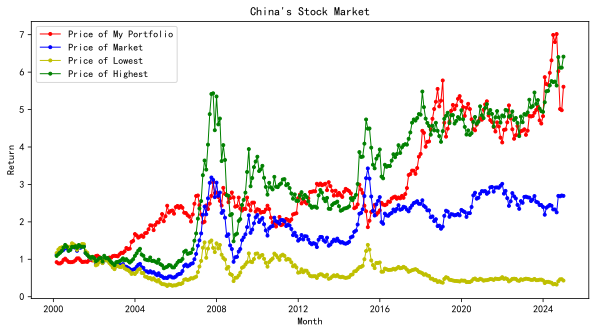

In [38]:
fig = plt.figure(figsize=(10, 5))
plt.plot(
    'price_portfolio',  
    '.-r', 
    label='Price of My Portfolio',  
    linewidth=1, 
    data=MYPOR)  
plt.title("China's Stock Market") 
plt.xlabel('Month') 
plt.ylabel('Return') 

plt.plot(
    'price_market', 
    '.-b', 
    label='Price of Market', 
    linewidth=1, 
    data=MYPOR) 

plt.plot(
    'price_p1', 
    '.-y', 
    label='Price of Lowest', 
    linewidth=1, 
    data=MYPOR) 

plt.plot(
    'price_pmax', 
    '.-g', 
    label='Price of Highest', 
    linewidth=1, 
    data=MYPOR) 
plt.legend() # 显示图例
fig = plt.gcf()
plt.show();

In [39]:
latest_month = portfolio['month'].max()
if pd.isna(latest_month):
    raise ValueError("无法定位最新月份，请检查 portfolio 数据是否为空。")
latest_month_value = portfolio.loc[portfolio['month'] == latest_month].copy()

print(f"最新一期数据: {latest_month.strftime('%Y-%m')}, 样本数量: {len(latest_month_value)}")

growth_stocks = latest_month_value.loc[latest_month_value['sort'] == 'P1'].copy()
growth_stocks = growth_stocks.sort_values('ep', ascending=True)

print(f"=== 成长股组合(P1 - 低EP)分析 ===")
print(f"公司数量: {len(growth_stocks)}")
print(f"平均EP值: {growth_stocks['ep'].mean():.4f}")
print(f"EP范围: {growth_stocks['ep'].min():.4f} 到 {growth_stocks['ep'].max():.4f}")
print(f"平均市值: {growth_stocks['totalvalue'].mean():.2f} 万元\n")

print("EP最低的20家成长股(市盈率最高):")
print(growth_stocks[['Stkcd', 'totalvalue', 'ep', 'ret']].head(20))

最新一期数据: 2024-11, 样本数量: 3093
=== 成长股组合(P1 - 低EP)分析 ===
公司数量: 310
平均EP值: -0.1146
EP范围: -1.1417 到 -0.0347
平均市值: 11406903645.26 万元

EP最低的20家成长股(市盈率最高):
         Stkcd    totalvalue        ep       ret
342146  600376  7.558126e+09 -1.141660 -0.001118
337157  600340  1.127151e+10 -1.027659  0.262040
440009  600881  5.880534e+09 -0.810666 -0.182113
369516  600569  5.342704e+09 -0.563060 -0.093801
377236  600606  3.260579e+10 -0.438367  0.108930
371466  600581  5.062295e+09 -0.379649 -0.097272
452668  601011  5.153138e+09 -0.377203  0.158365
430633  600841  5.528030e+09 -0.370723 -0.014153
397521  600691  5.654837e+09 -0.365228 -0.005302
381089  600622  5.788786e+09 -0.361750 -0.221320
147767  002305  4.144776e+09 -0.346784  0.120948
3196    000016  8.030867e+09 -0.314147 -0.286629
13642   000069  2.451516e+10 -0.305915  0.029287
18953   000402  1.195572e+10 -0.295636  0.119330
408822  600743  4.340287e+09 -0.291724  0.015365
244058  300423  4.169145e+09 -0.287230  0.234870
66784   000761  1.2

In [40]:
# 查看价值股组合(Pmax - 高EP值)的样本
value_stocks = latest_month_value[latest_month_value['sort'] == 'Pmax'].copy()
value_stocks = value_stocks.sort_values('ep', ascending=False)

print(f"=== 价值股组合(Pmax - 高EP)分析 ===")
print(f"公司数量: {len(value_stocks)}")
print(f"平均EP值: {value_stocks['ep'].mean():.4f}")
print(f"EP范围: {value_stocks['ep'].min():.4f} 到 {value_stocks['ep'].max():.4f}")
print(f"平均市值: {value_stocks['totalvalue'].mean():.2f} 万元\n")

# 显示EP最高的20家价值股
print("EP最高的20家价值股(市盈率最低):")
print(value_stocks[['Stkcd', 'totalvalue', 'ep', 'ret']].head(20))

=== 价值股组合(Pmax - 高EP)分析 ===
公司数量: 310
平均EP值: 0.1149
EP范围: 0.0751 到 0.2787
平均市值: 69544096809.90 万元

EP最高的20家价值股(市盈率最低):
         Stkcd    totalvalue        ep       ret
24367   000498  9.912333e+09  0.278727 -0.016622
401423  600710  1.164314e+10  0.270822 -0.013313
468561  601668  2.488297e+11  0.253724 -0.007762
320206  600248  1.706715e+10  0.245478 -0.003321
478459  601997  2.208344e+10  0.238759  0.007229
465523  601577  3.438428e+10  0.234661  0.002403
274651  600015  1.204760e+11  0.227398  0.069603
458832  601186  1.064050e+11  0.218434  0.034716
458387  601169  1.209379e+11  0.213837  0.011271
356     000001  2.208393e+11  0.211063 -0.001118
475661  601919  1.734226e+11  0.210491 -0.069019
472403  601838  6.071833e+10  0.203985  0.032648
457991  601166  3.749761e+11  0.199498 -0.013700
475271  601916  6.247886e+10  0.197068  0.020008
472163  601818  1.670645e+11  0.196119  0.042360
463924  601390  1.316822e+11  0.195535 -0.001118
489568  603323  9.652298e+09  0.195198  0.040466

In [41]:
# 获取这20家价值股的详细信息
value_stock_codes = ['000498', '600710', '601668', '600248', '601997', '601577', '600015', '601186', 
                     '601169', '000001', '601919', '601838', '601166', '601916', '601818', '601390', 
                     '603323', '600919', '601229', '600502']

# 创建价值股公司信息字典
value_company_info = {
    '000498': ('山东路桥', '公路桥梁建设', '山东济南'),
    '600710': ('苏美达', '机电设备进出口', '江苏南京'),
    '601668': ('中国建筑', '建筑工程施工', '北京市'),
    '600248': ('陕西建工', '建筑工程施工', '陕西西安'),
    '601997': ('贵阳银行', '商业银行', '贵州贵阳'),
    '601577': ('长沙银行', '商业银行', '湖南长沙'),
    '600015': ('华夏银行', '股份制商业银行', '北京市'),
    '601186': ('中国铁建', '铁路工程建设', '北京市'),
    '601169': ('北京银行', '城市商业银行', '北京市'),
    '000001': ('平安银行', '股份制商业银行', '广东深圳'),
    '601919': ('中远海控', '集装箱航运', '上海市'),
    '601838': ('成都银行', '城市商业银行', '四川成都'),
    '601166': ('兴业银行', '股份制商业银行', '福建福州'),
    '601916': ('浙商银行', '股份制商业银行', '浙江杭州'),
    '601818': ('光大银行', '股份制商业银行', '北京市'),
    '601390': ('中国中铁', '铁路工程建设', '北京市'),
    '603323': ('苏农银行', '农村商业银行', '江苏苏州'),
    '600919': ('江苏银行', '城市商业银行', '江苏南京'),
    '601229': ('上海银行', '城市商业银行', '上海市'),
    '600502': ('安徽建工', '建筑工程施工', '安徽合肥')
}

# 创建详细信息DataFrame
value_info = []
for idx, row in value_stocks[['Stkcd', 'totalvalue', 'ep', 'ret']].head(20).iterrows():
    stkcd = row['Stkcd']
    if stkcd in value_company_info:
        name, industry, location = value_company_info[stkcd]
        value_info.append({
            '股票代码': stkcd,
            '公司名称': name,
            '主营业务': industry,
            '注册地': location,
            '总市值(亿元)': f"{row['totalvalue']/1e8:.2f}",
            'EP值': f"{row['ep']:.4f}",
            '市盈率(PE)': f"{1/row['ep']:.2f}",
            '当期收益率': f"{row['ret']:.4%}"
        })

value_info_df = pd.DataFrame(value_info)
print("\n=== EP最高的20家价值股详细信息 ===")
print(value_info_df.to_string(index=False))


=== EP最高的20家价值股详细信息 ===
  股票代码 公司名称    主营业务  注册地 总市值(亿元)    EP值 市盈率(PE)    当期收益率
000498 山东路桥  公路桥梁建设 山东济南   99.12 0.2787    3.59 -1.6622%
600710  苏美达 机电设备进出口 江苏南京  116.43 0.2708    3.69 -1.3313%
601668 中国建筑  建筑工程施工  北京市 2488.30 0.2537    3.94 -0.7762%
600248 陕西建工  建筑工程施工 陕西西安  170.67 0.2455    4.07 -0.3321%
601997 贵阳银行    商业银行 贵州贵阳  220.83 0.2388    4.19  0.7229%
601577 长沙银行    商业银行 湖南长沙  343.84 0.2347    4.26  0.2403%
600015 华夏银行 股份制商业银行  北京市 1204.76 0.2274    4.40  6.9603%
601186 中国铁建  铁路工程建设  北京市 1064.05 0.2184    4.58  3.4716%
601169 北京银行  城市商业银行  北京市 1209.38 0.2138    4.68  1.1271%
000001 平安银行 股份制商业银行 广东深圳 2208.39 0.2111    4.74 -0.1118%
601919 中远海控   集装箱航运  上海市 1734.23 0.2105    4.75 -6.9019%
601838 成都银行  城市商业银行 四川成都  607.18 0.2040    4.90  3.2648%
601166 兴业银行 股份制商业银行 福建福州 3749.76 0.1995    5.01 -1.3700%
601916 浙商银行 股份制商业银行 浙江杭州  624.79 0.1971    5.07  2.0008%
601818 光大银行 股份制商业银行  北京市 1670.65 0.1961    5.10  4.2360%
601390 中国中铁  铁路工程建设  北京市 1316.82 0.1955    5.11 -0.1118%
603323

In [42]:
# 计算投资组合的Sharpe Ratio
sharpe_ratio = MYPOR['My_portfolio'].mean() / MYPOR['My_portfolio'].std() * np.sqrt(12)
print(f"Sharpe Ratio: {sharpe_ratio}")

Sharpe Ratio: 0.43187365483039486


In [43]:
# 计算累积收益率
MYPOR['cumulative_return'] = (1 + MYPOR['My_portfolio']).cumprod()

# 计算滚动最大值
MYPOR['rolling_max'] = MYPOR['cumulative_return'].cummax()

# 计算回撤
MYPOR['drawdown'] = MYPOR['cumulative_return'] / MYPOR['rolling_max'] - 1

# 计算最大回撤
max_drawdown = MYPOR['drawdown'].min()
print(f"Maximum Drawdown: {max_drawdown}")

Maximum Drawdown: -0.39277701682231836


In [44]:
# 找出最大回撤的时间
max_drawdown_end = MYPOR['drawdown'].idxmin() # 返回 Series 中最小值的索引
max_drawdown_start = MYPOR.loc[:max_drawdown_end, 'cumulative_return'].idxmax() # 这部分代码选择了从数据开始到 max_drawdown_end 时间点之间的所有累积收益率

print(f"Maximum Drawdown: {max_drawdown}")
print(f"Maximum Drawdown Start Date: {max_drawdown_start}")
print(f"Maximum Drawdown End Date: {max_drawdown_end}")

Maximum Drawdown: -0.39277701682231836
Maximum Drawdown Start Date: 2013-06-30 00:00:00
Maximum Drawdown End Date: 2015-05-31 00:00:00


In [45]:
portfolio_value

sort,P1,P2,P3,P4,P5,P6,P7,P8,P9,Pmax,My_portfolio
month,,,,,,,,,,,
2000-02-29,0.166357,0.165800,0.138800,0.107954,0.151389,0.094652,0.070353,0.091512,0.061355,0.089514,-0.076843
2000-03-31,0.079685,-0.001584,0.007175,0.019191,0.038322,0.037642,0.055191,0.052076,0.065257,0.043202,-0.036483
2000-04-30,0.034669,-0.029604,-0.007395,-0.011148,0.028850,0.022619,0.041919,0.038311,0.000506,0.032381,-0.002288
2000-05-31,0.012548,0.006910,0.006493,0.043984,0.024917,-0.004197,0.028055,0.005743,0.028147,0.044220,0.031672
2000-06-30,-0.001656,-0.000891,-0.025373,0.002718,0.000285,0.014655,0.042497,0.047704,0.060273,0.069934,0.071590
...,...,...,...,...,...,...,...,...,...,...,...
2024-08-31,-0.050075,-0.051880,-0.069000,-0.054196,-0.044302,-0.045110,-0.028238,-0.035817,-0.019721,-0.018440,0.031635
2024-09-30,0.276281,0.241689,0.238392,0.224931,0.206499,0.233799,0.213797,0.214329,0.189604,0.134840,-0.141441
2024-10-31,0.123495,0.138160,0.067615,0.099600,0.030935,0.010993,-0.059571,-0.040672,-0.040566,-0.044238,-0.167733


In [46]:
# 定义不同的时间段
time_periods = [
    ('2000-02-29', '2007-12-31', '2000-2007'),
    ('2008-01-31', '2015-12-31', '2008-2015'),
    ('2016-01-31', '2024-12-31', '2016-2024')
]

# 计算每个时间段的价值溢价
period_results = []

for start_date, end_date, period_name in time_periods:
    # 筛选该时间段的数据
    period_data = portfolio_value[
        (portfolio_value.index >= start_date) & 
        (portfolio_value.index <= end_date)
    ].copy()
    
    if len(period_data) == 0:
        continue
    
    # 计算价值溢价 (Pmax - P1)
    value_premium_series = period_data['My_portfolio']
    
    # 计算统计量
    mean_premium = value_premium_series.mean()
    std_premium = value_premium_series.std()
    t_stat, p_value = stats.ttest_1samp(value_premium_series.dropna(), 0)
    
    # 年化收益率和夏普比率
    annual_ret = mean_premium * 12
    annual_std = std_premium * np.sqrt(12)
    sharpe = annual_ret / annual_std if annual_std > 0 else 0
    
    # 胜率
    win_rate = (value_premium_series > 0).sum() / len(value_premium_series.dropna())
    
    # 累积收益
    cumulative_ret = (1 + value_premium_series).prod() - 1
    
    period_results.append({
        '时期': period_name,
        '样本数': len(value_premium_series.dropna()),
        '月均溢价(%)': f'{mean_premium*100:.3f}',
        '年化溢价(%)': f'{annual_ret*100:.2f}',
        '年化波动(%)': f'{annual_std*100:.2f}',
        '夏普比率': f'{sharpe:.3f}',
        't统计量': f'{t_stat:.3f}',
        'p值': f'{p_value:.4f}',
        '胜率(%)': f'{win_rate*100:.2f}',
        '累积收益(%)': f'{cumulative_ret*100:.2f}'
    })

results_df = pd.DataFrame(period_results)
print("\n不同时期的价值效应:")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)
print("\n*** p<0.01, ** p<0.05, * p<0.1")


不同时期的价值效应:
       时期  样本数 月均溢价(%) 年化溢价(%) 年化波动(%)  夏普比率  t统计量     p值 胜率(%) 累积收益(%)
2000-2007   95   1.240   14.88   19.77 0.753 2.118 0.0368 57.89  178.40
2008-2015   96   0.020    0.24   23.04 0.010 0.030 0.9765 48.96  -17.16
2016-2024  108   1.004   12.04   20.69 0.582 1.746 0.0836 59.26  143.19

*** p<0.01, ** p<0.05, * p<0.1


In [47]:
# 使用市场收益率界定牛熊市
# 牛市: 市场收益率 > 中位数; 熊市: 市场收益率 < 中位数

# 首先检查 portfolio_value 的结构
print("portfolio_value 的列名:", portfolio_value.columns.tolist())
print("\nportfolio_value 的前几行:")
print(portfolio_value.head())

# 确保索引是 datetime 类型
if not isinstance(portfolio_value.index, pd.DatetimeIndex):
    portfolio_value.index = pd.to_datetime(portfolio_value.index)

# 获取市场收益率数据
# 假设 Market_ret 中有月度收益率列,需要确认列名
print("\nMarket_ret 的列名:", Market_ret.columns.tolist())

# 合并市场收益率数据 (使用月份作为键)
portfolio_with_market = portfolio_value.copy()
portfolio_with_market = portfolio_with_market.reset_index()

# 与市场收益率合并
market_data = Market_ret[['MKT']].copy()
portfolio_with_market = portfolio_with_market.merge(
    market_data,
    left_on='month',
    right_on='month',
    how='left',
    suffixes=('', '_market')
)

# 计算市场收益率的中位数
market_median = portfolio_with_market['MKT'].median()

# 分类市场状态
portfolio_with_market['market_state'] = portfolio_with_market['MKT'].apply(
    lambda x: '牛市' if x > market_median else '熊市'
)

# 分别计算牛市和熊市的价值溢价
market_states = ['牛市', '熊市']
state_results = []

for state in market_states:
    state_data = portfolio_with_market[portfolio_with_market['market_state'] == state]
    
    # 价值溢价 (My_portfolio 列)
    value_premium_data = state_data['My_portfolio'].dropna()
    
    if len(value_premium_data) > 0:
        mean_premium = value_premium_data.mean()
        std_premium = value_premium_data.std()
        
        # t检验
        t_stat, p_value = stats.ttest_1samp(value_premium_data, 0)
        
        # 胜率 (价值溢价为正的月份占比)
        win_rate = (value_premium_data > 0).sum() / len(value_premium_data) * 100
        
        # 年化收益
        annual_ret = mean_premium * 12
        
        state_results.append({
            '市场状态': state,
            '样本数': len(value_premium_data),
            '月均溢价(%)': f'{mean_premium*100:.3f}',
            '年化溢价(%)': f'{annual_ret*100:.2f}',
            't统计量': f'{t_stat:.3f}',
            'p值': f'{p_value:.4f}',
            '胜率(%)': f'{win_rate:.1f}'
        })
    else:
        state_results.append({
            '市场状态': state,
            '样本数': 0,
            '月均溢价(%)': 'N/A',
            '年化溢价(%)': 'N/A',
            't统计量': 'N/A',
            'p值': 'N/A',
            '胜率(%)': 'N/A'
        })

state_df = pd.DataFrame(state_results)
print("\n不同市场状态下的价值效应:")
print("="*100)
print(state_df.to_string(index=False))
print("="*100)
print(f"\n注: 以市场月度收益率中位数({market_median*100:.3f}%)作为牛熊市分界线")

portfolio_value 的列名: ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'Pmax', 'My_portfolio']

portfolio_value 的前几行:
sort              P1        P2        P3        P4        P5        P6  \
month                                                                    
2000-02-29  0.166357  0.165800  0.138800  0.107954  0.151389  0.094652   
2000-03-31  0.079685 -0.001584  0.007175  0.019191  0.038322  0.037642   
2000-04-30  0.034669 -0.029604 -0.007395 -0.011148  0.028850  0.022619   
2000-05-31  0.012548  0.006910  0.006493  0.043984  0.024917 -0.004197   
2000-06-30 -0.001656 -0.000891 -0.025373  0.002718  0.000285  0.014655   

sort              P7        P8        P9      Pmax  My_portfolio  
month                                                             
2000-02-29  0.070353  0.091512  0.061355  0.089514     -0.076843  
2000-03-31  0.055191  0.052076  0.065257  0.043202     -0.036483  
2000-04-30  0.041919  0.038311  0.000506  0.032381     -0.002288  
2000-05-31  0.028055  0